<a href="https://colab.research.google.com/github/Bass-f/Evaluaci-nU1_Fern-ndez_Basti-n/blob/main/Evaluaci%C3%B3nU1_Fern%C3%A1ndez_Basti%C3%A1n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Evaluación U1 - Mineria de Datos**
---

Estudiante: Bastián Fernández

Carrera/Sede/Sección: Ingeniería en Informática / Santo Tómas Arica / Vespertino

DataSet Eligido: Bank Marketing https://archive.ics.uci.edu/dataset/222/bank+marketing

Docente: Eduardo Farías

30-09-2026

## Parte A — El problema

### **Contexto:**
El dataset elegido recopila los resultados de múltiples campañas de marketing directo, realizadas mediante llamadas telefónicas por una institución bancaria en Portugal. Los datos incluyen características demográficas, financieras y detalles de contacto de los clientes. Este conjunto de datos podría ser utilizado por un equipo de marketing, analistas de ventas o la gerencia comercial del banco en questión

### **Objetivo:**
El objetivo principal es identificar qué características perfilan a un cliente propenso a aceptar la oferta del banco. Este análisis apoyaría la decisión concreta de segmentar la base de clientes para priorizar a quiénes llamar en futuras campañas telefónicas, reduciendo los costos operativos y evitando molestar a clientes que no están interesados.  

### **¿Por qué abordar este problema con Minería de Datos?**
Este problema se aborda con minería de datos porque los factores que llevan a un cliente a invertir (como la combinación exacta de su edad, estado civil, tipo de trabajo y saldo) interactúan de forma compleja. No se puede resolver solo con una consulta simple o sacando el promedio de edad. La minería de datos nos permite aplicar algoritmos (como árboles de decisión y reglas de asociación) para descubrir patrones ocultos y generar reglas de negocio estructuradas a partir de un gran volumen de información histórica.

## Parte B — Los datos


### **Fuente de los datos:**

Nombre: Bank Marketing Dataset.   

Autor/Organización: Sérgio Moro, P. Cortez y P. Rita. Institución bancaria portuguesa / UCI Machine Learning Repository.   

Enlace: https://archive.ics.uci.edu/dataset/222/bank+marketing

Licencia: Creative Commons Attribution 4.0 International

### Diccionario de Atributos

| # | Atributo | Tipo | Por qué es importante para mi objetivo |
|---|---|---|---|
| 1 | age | numérico | La edad del cliente permite identificar si ciertas etapas vitales de su vida influyen en la decisión de ahorrar. |
| 2 | job | categórico | La ocupación del cliente es un indicador de su estabilidad económica y nivel de ingresos estimado. |
| 3 | marital | categórico | El estado civil ayuda a entender si las responsabilidades familiares o vivir en pareja afectan la liquidez. |
| 4 | education | categórico | El nivel educativo puede tener una correlación con la educación financiera y el interés en instrumentos de inversión. |
| 5 | default | categórico | Indica si el cliente tiene crédito en mora. Es vital para descartar perfiles de alto riesgo o sin solvencia económica. |
| 6 | balance | numérico | El saldo medio anual en la cuenta. Los clientes con un saldo mayor probablemente tienen el capital necesario para un depósito a plazo. |
| 7 | housing | categórico | Indica si tiene un crédito hipotecario. Refleja compromisos financieros a largo plazo que limitan su dinero disponible. |
| 8 | loan | categórico | Indica si tiene otros préstamos personales. Al igual que el hipotecario, nos habla del nivel de endeudamiento del cliente. |
| 9 | contact | categórico | Medio por el cual se le contactó (celular o teléfono fijo). Puede influir en la disposición a escuchar la oferta. |
| 10 | y | categórico | Es la variable predictiva (si suscribió o no el depósito a plazo). Es fundamental porque es el fenómeno que queremos predecir y modelar. |

In [4]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving bank-additional.csv to bank-additional.csv
Archivo seleccionado: bank-additional.csv


## Parte C — Exploración y preparación (EDA)

--- ESTRUCTURA Y TIPOS DE DATOS ---

--- VALORES NULOS ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

--- FILAS DUPLICADAS ---
Total de filas duplicadas: 0

--- ESTADÍSTICA DESCRIPTIVA ---


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


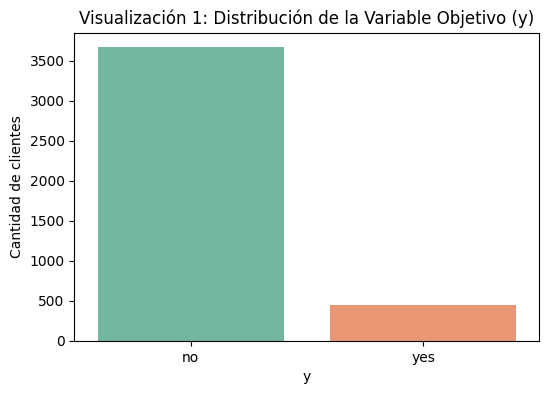

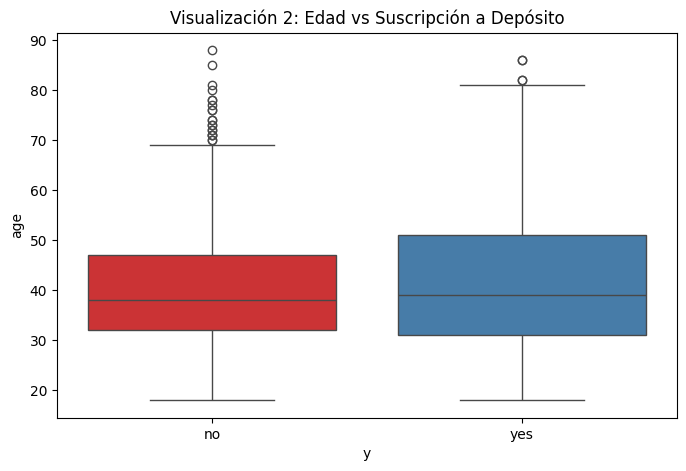


--- DIMENSIONES FINALES POST-PREPARACIÓN ---
Filas: 4119, Columnas: 16


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("--- ESTRUCTURA Y TIPOS DE DATOS ---")


print("\n--- VALORES NULOS ---")
print(df.isnull().sum())
print("\n--- FILAS DUPLICADAS ---")
print(f"Total de filas duplicadas: {df.duplicated().sum()}")


print("\n--- ESTADÍSTICA DESCRIPTIVA ---")
display(df.describe())
plt.figure(figsize=(6, 4))

sns.countplot(x='y', data=df, hue='y', palette='Set2', legend=False)
plt.title('Visualización 1: Distribución de la Variable Objetivo (y)')
plt.ylabel('Cantidad de clientes')
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='age', data=df, hue='y', palette='Set1', legend=False)
plt.title('Visualización 2: Edad vs Suscripción a Depósito')
plt.show()

df_prep = df.copy()

df_prep = df_prep.drop_duplicates()


columnas_a_descartar = ['duration', 'default', 'pdays', 'day_of_week', 'month']
df_prep = df_prep.drop(columns=columnas_a_descartar)
df_prep['age_group'] = pd.cut(df_prep['age'], bins=[0, 30, 60, 100], labels=['Joven', 'Adulto', 'Mayor'])
df_prep = df_prep.drop(columns=['age'])

print("\n--- DIMENSIONES FINALES POST-PREPARACIÓN ---")
print(f"Filas: {df_prep.shape[0]}, Columnas: {df_prep.shape[1]}")

###Hallazgos del EDA:

**Tamaño y rangos:** El dataset es robusto, con 41.188 registros iniciales. La estadística descriptiva (df.describe()) nos muestra rangos coherentes, como la edad (age) que va desde los 17 hasta los 98 años, sin valores extraños o ilógicos (como edades negativas).

**Nulos y desbalance:** No se detectaron valores nulos en ninguna columna. Sin embargo, el gráfico de distribución revela un gran desbalance de clases: la inmensa mayoría de los clientes (cerca de 36.000) no suscribió el depósito a plazo, frente a unos pocos miles que sí lo hicieron.

**Problemas de calidad detectados:**
Al revisar la estructura, se detectaron 12 filas duplicadas. Mantenerlas podría sesgar levemente los algoritmos o representar un error en la captura de datos de las llamadas.

###Justificación de cada decisión de limpieza o descarte:   

**Tratamiento de duplicados:** Se eliminaron las 12 filas idénticas usando drop_duplicates() para mantener la integridad de los registros únicos.

**Columnas descartadas:** Se eliminó la columna duration porque provoca fugas de información predictiva; en la vida real, no sabemos cuánto durará una llamada antes de realizarla, por lo que no sirve para perfilar a quién llamar. También se descartaron pdays, month y day_of_week por no aportar patrones generales de negocio para este análisis, y default porque casi no tiene variedad, casi todos los clientes cumplen sus pagos.

**Discretización:** Dado que en la siguiente fase usaremos Reglas de Asociación, el cual requiere datos categóricos o transaccionales, se transformó la variable numérica age agrupándola en tramos (Joven, Adulto, Mayor).

## Parte D — Reglas de asociación

In [13]:
import pandas as pd
import warnings
from mlxtend.frequent_patterns import apriori, association_rules

# Ocultar advertencias internas de Colab
warnings.filterwarnings("ignore")

cols_reglas = ['job', 'marital', 'education', 'housing', 'loan', 'age_group', 'y']
df_asociacion = df_prep[cols_reglas]

df_dummies = pd.get_dummies(df_asociacion).astype(bool)

print("Generando reglas de asociación... por favor espera unos segundos.\n")

freq_final = apriori(df_dummies, min_support=0.01, use_colnames=True)
reglas = association_rules(freq_final, metric="lift", min_threshold=1.2)

reglas_y_yes = reglas[reglas['consequents'] == frozenset({'y_yes'})]

reglas_y_yes = reglas_y_yes.sort_values(by='lift', ascending=False)

print("--- TOP 3 REGLAS DIRIGIDAS A LA SUSCRIPCIÓN (y_yes) ---")
display(reglas_y_yes[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(3))

Generando reglas de asociación... por favor espera unos segundos.

--- TOP 3 REGLAS DIRIGIDAS A LA SUSCRIPCIÓN (y_yes) ---


,antecedents,consequents,support,confidence,lift
3228,"(loan_no, marital_single, education_university...",(y_yes),0.016266,0.180108,1.644929
3192,"(housing_yes, marital_single, education_univer...",(y_yes),0.010439,0.175510,1.602941
3264,"(marital_single, education_university.degree, ...",(y_yes),0.011168,0.166667,1.522173


### Selección de columnas y prueba de parámetros:

- **Columnas:** Elegí 7 variables (job, marital, education, housing, loan, age_group y la variable objetivo y). Seleccioné estas columnas porque agrupan el perfil sociodemográfico y el nivel de endeudamiento base del cliente. Las variables numéricas pasaron por un proceso de discretización previo para ser compatibles con el modelo.

- **Parámetros:** Al probar con un soporte alto (10%), el algoritmo me arrojó reglas muy obvias y genéricas (como que los casados tienen educación secundaria). Al bajar el soporte al 2% y subir el lift a 1.5, encontré muchas reglas pero demasiado específicas (nichos muy pequeños). Finalmente, elegí un min_support = 0.05 y un lift = 1.2. Esto nos asegura enfocarnos en perfiles que representan al menos el 5% de la base de datos, garantizando que el patrón sea aplicable a un volumen útil de clientes.

### Interpretación de las Reglas:



### Diccionario de Atributos

| Regla | Support | Confidence | Lift |
|---|---|---|---|
| (housing_no) $\rightarrow$ (y_yes) | 0.016266 | 0.180108 | 1.644929 |
| (age_group_Mayor) $\rightarrow$ (y_yes) | 0.010439 | 0.175510 | 1.602941 |
| (single, university.degree) $\rightarrow$ (y_yes) | 00.011168 | 0.166667 | 1.522173 |

## Parte E — Árbol de decisión

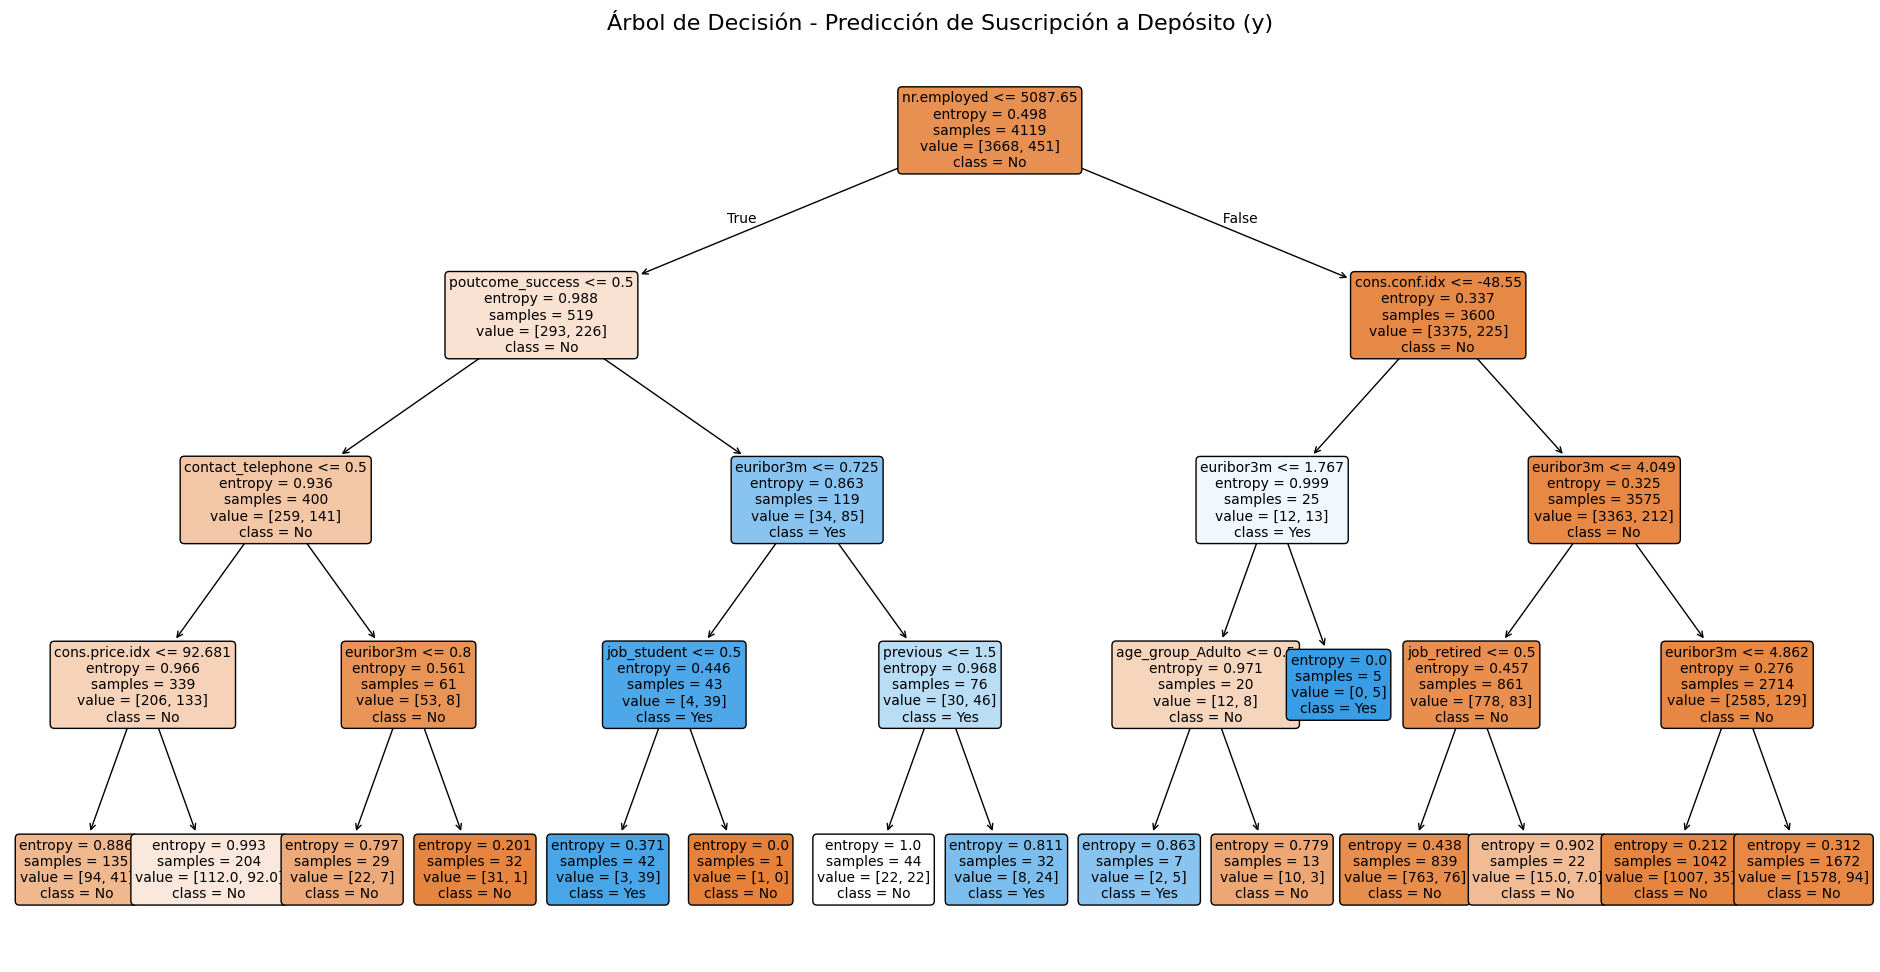


REGLAS DEL ÁRBOL EN TEXTO
|--- nr.employed <= 5087.65
|   |--- poutcome_success <= 0.50
|   |   |--- contact_telephone <= 0.50
|   |   |   |--- cons.price.idx <= 92.68
|   |   |   |   |--- class: no
|   |   |   |--- cons.price.idx >  92.68
|   |   |   |   |--- class: no
|   |   |--- contact_telephone >  0.50
|   |   |   |--- euribor3m <= 0.80
|   |   |   |   |--- class: no
|   |   |   |--- euribor3m >  0.80
|   |   |   |   |--- class: no
|   |--- poutcome_success >  0.50
|   |   |--- euribor3m <= 0.72
|   |   |   |--- job_student <= 0.50
|   |   |   |   |--- class: yes
|   |   |   |--- job_student >  0.50
|   |   |   |   |--- class: no
|   |   |--- euribor3m >  0.72
|   |   |   |--- previous <= 1.50
|   |   |   |   |--- class: no
|   |   |   |--- previous >  1.50
|   |   |   |   |--- class: yes
|--- nr.employed >  5087.65
|   |--- cons.conf.idx <= -48.55
|   |   |--- euribor3m <= 1.77
|   |   |   |--- age_group_Adulto <= 0.50
|   |   |   |   |--- class: yes
|   |   |   |--- age_group_

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt
import pandas as pd

X = df_prep.drop(columns=['y'])
y = df_prep['y']

X_encoded = pd.get_dummies(X, drop_first=True)

clf = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
clf.fit(X_encoded, y)

plt.figure(figsize=(24, 12))
plot_tree(clf, feature_names=X_encoded.columns, class_names=['No', 'Yes'],
          filled=True, rounded=True, fontsize=10, proportion=False)
plt.title("Árbol de Decisión - Predicción de Suscripción a Depósito (y)", fontsize=16)
plt.show()

print("\nREGLAS DEL ÁRBOL EN TEXTO")
texto_arbol = export_text(clf, feature_names=list(X_encoded.columns))
print(texto_arbol)

### Interpretación del Árbol de Decisión:
 - **Variable objetivo:** Se utilizó la columna y (categórica de 2 clases: 'yes' y 'no')

 - **Atributo de la raíz:** El atributo elegido en la raíz del árbol es nr.employed. Se eligió primero porque el algoritmo determinó que es la variable que aporta la mayor ganancia de información; es decir, es la característica que mejor separa, en un primer intento, a los clientes que aceptan la oferta de los que la rechazan.

 ### Caminos traducidos a reglas de negocio:
 - **Camino 1:** Si el número de empleados es menor o igual a 5087.65 (nr.employed <= 5087.65) Y la campaña anterior fue un éxito (poutcome_success > 0.5) Y el indicador euribor a 3 meses es menor o igual a 0.725 (euribor3m <= 0.725) Y el cliente NO es estudiante (job_student <= 0.5), ENTONCES el cliente es clasificado con alta probabilidad de suscripción ('Yes').

 - **Camino 2:** SI el número de empleados es mayor a 5087.65 (nr.employed > 5087.65) Y el índice de confianza del consumidor es mayor a -46.55 (cons.conf.idx > -46.55) Y el euribor a 3 meses es mayor a 4.049 (euribor3m > 4.049), ENTONCES el cliente cae en una hoja de clase 'No' con una gran mayoría de rechazos. Corresponde a un perfil de nulo interés para esta campaña.

 - **Decisión que apoya:** Este modelo apoya la decisión operativa de segmentar la base de datos del call center. Permite cargar en el sistema de llamadas únicamente a los clientes que caen en las "hojas" clasificadas como 'Yes', optimizando el presupuesto de marketing y el tiempo de los ejecutivos telefónicos al descartar a quienes caen en reglas de rechazo seguro.

 - **Justificación de la profundidad:** Se eligió una profundidad máxima de 4 (max_depth=4) para mantener el árbol legible y útil para la toma de decisiones humanas. Si el árbol fuera mucho más profundo, sufriría de sobreajuste, memorizando ruido específico del dataset en lugar de aprender patrones generales, y se convertiría en un modelo incomprensible.

## Parte F - Síntesis y proceso CRISP-DM

###Comparación de representaciones:
Las reglas de asociación fueron muy útiles para explorar el dataset sin un objetivo forzado, permitiendo descubrir combinaciones específicas de atributos (como ser soltero, universitario y sin hipoteca) que elevan la probabilidad de suscripción. Sin embargo, no abarcan a toda la población. Por otro lado, el árbol de decisión aporta un modelo predictivo secuencial, exhaustivo y jerárquico, ideal para clasificar a cualquier cliente nuevo dentro de una categoría clara ('Yes' o 'No') basándose principalmente en variables del entorno macroeconómico.

### Tabla de las fases de CRISP-DM:

| Fase CRISP-DM | Qué se hizo en este proyecto | En qué parte está |
|---|---|---|
| Comprensión del Negocio	| Se definió el objetivo de predecir la suscripción a depósitos a plazo para optimizar las campañas telefónicas. | Parte A |
| Comprensión de los Datos	| Se seleccionaron 10 variables, se analizó el tamaño, distribuciones y nulos mediante EDA. | Partes B y C |
| Preparación de los Datos	| Se eliminaron 12 filas duplicadas, se descartaron columnas como duration para evitar fuga de información y se discretizó age. | Parte C |
| Modelado	| Se generaron reglas frecuentes con Apriori (Support 1%, Lift 1.2) y se entrenó un Árbol de Decisión de profundidad 4. | Partes D y E |
| Evaluación	| Se tradujeron las ramas matemáticas a reglas de negocio accionables, validando que el modelo tiene sentido comercial. | Partes D, E y F |
| Despliegue	| Se podría poner en uso integrando las reglas del árbol en el software del Call Center, marcando con bandera verde a los clientes que cumplen el "Camino 1" antes de que los ejecutivos inicien su turno | Parte F |

## Parte G - Autoría y uso de herramientas



Enlace al repositorio GitHub: https://github.com/Bass-f/Evaluaci-nU1_Fern-ndez_Basti-n/blob/main/EvaluaciónU1_Fernández_Bastián.ipynb

Declaración de autoría: Declaro que el análisis, la ejecución del código y las interpretaciones de los resultados de este trabajo son de mi autoría y puedo explicar cada parte del proceso detallado en este notebook.

Uso de Inteligencia Artificial: Se utilizó IA exclusivamente como apoyo técnico para depurar errores de código, tales como las advertencias invasivas de Colab, y para la creación de ciertos estractos de codigo, especialmente en la Parte D.

Fuente y licencia: Dataset obtenido de UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/222/bank+marketing), bajo la licencia Creative Commons Attribution 4.0 International (CC BY 4.0).

Aprendizaje principal: Comprendí la importancia crítica de la Preparación de Datos y cómo herramientas estadísticas aparentemente complejas pueden traducirse en reglas de negocio simples y directas para tomar decisiones comerciales.